<div style="
    background: linear-gradient(135deg, #0f0f0f, #1a1a2e);
    padding: 30px;
    border-radius: 12px;
    border: 1px solid #2a2a4a;
    color: white;
    font-family: Arial;
">

<h1 style="color:#e94560;"> Predict Claim Denials Before Submission</h1>

<p style="font-size:16px;">
XGBoost + SHAP + ROI Simulator for Healthcare Revenue Cycle AI
</p>

<hr style="border:1px solid #2a2a4a;">

<p>
<b>Author:</b> Nudrat Abbas<br>
<b>Dataset:</b> DenialIQ (120K Claims)<br>
<b>Goal:</b> Predict denials BEFORE submission → save revenue
</p>

</div>

In [1]:
# =============================================================
# Setup
# =============================================================

# !pip install shap xgboost --quiet

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("Environment ready")

Environment ready


In [2]:
# =============================================================
# Load Dataset (OS-based)
# =============================================================

DATA_PATH = "/kaggle/input/datasets/nudratabbas/denialiq-120k-medical-claims-x12-denial-codes"

print("Files in dataset:")
print(os.listdir(DATA_PATH))

claims = pd.read_csv(os.path.join(DATA_PATH, "claims_main.csv"))
splits = pd.read_csv(os.path.join(DATA_PATH, "train_test_split.csv"))
denial_labels = pd.read_csv(os.path.join(DATA_PATH, "denial_labels.csv"))
payer_rules = pd.read_csv(os.path.join(DATA_PATH, "payer_rules (1).csv"))

# Merge labels (IMPORTANT FIX)
claims = claims.merge(denial_labels, on="claim_id", how="left")

print("\nShapes:")
print("Claims:", claims.shape)
print("Splits:", splits.shape)

Files in dataset:
['payer_rules (1).csv', 'data_dictionary.csv', 'denial_labels.csv', 'claims_main.csv', 'llm_finetune (1).jsonl', 'train_test_split.csv']

Shapes:
Claims: (120000, 33)
Splits: (120000, 3)


<div style="
    background:#2a2a4a;
    padding:20px;
    border-radius:10px;
    color:white;
">

<h2>Why This Matters</h2>

<ul>
<li> 28% of claims are denied</li>
<li> $25–$118 cost per denial rework</li>
<li> 50% never resubmitted</li>
</ul>

<p>
 Goal: Catch high-risk claims BEFORE submission
</p>

</div>

In [3]:
# =============================================================
# Basic EDA
# =============================================================

claims["is_denied"] = (claims["outcome"] == "denied").astype(int)

denial_rate = claims["is_denied"].mean()

print(f"Denial Rate: {denial_rate:.2%}")

claims["payer_type"].value_counts().head()

Denial Rate: 28.05%


payer_type
Commercial_PPO        30016
Medicare_FFS          26300
Medicare_Advantage    21758
Medicaid_Managed      17996
Commercial_HMO        15458
Name: count, dtype: int64

## FEATURE ENGINEERING

In [4]:
# =============================================================
# Feature Engineering
# =============================================================

df = claims.merge(splits, on="claim_id", how="left")

# Safe columns
df["prior_auth_required"] = np.random.randint(0, 2, len(df))
df["prior_auth_obtained"] = np.random.randint(0, 2, len(df))
df["documentation_completeness"] = np.random.uniform(0.4, 1.0, len(df))
df["secondary_dx_count"] = np.random.randint(0, 4, len(df))

# Target
df["target"] = (df["outcome"] == "denied").astype(int)

# Encode categoricals
from sklearn.preprocessing import LabelEncoder

cat_cols = ["payer_type", "provider_specialty", "cpt_code"]

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

FEATURES = cat_cols + [
    "claim_amount_usd",
    "prior_auth_required",
    "documentation_completeness",
    "secondary_dx_count"
]

print("Features ready")

Features ready


<div style="
    background:#1a1a2e;
    padding:15px;
    border-left:5px solid #533483;
    border-radius:8px;
    color:white;
">
<h2> Model Training (XGBoost)</h2>
</div>

In [5]:
# =============================================================
# Train Model
# =============================================================

from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import roc_auc_score

train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "val"]

X_train = train_df[FEATURES]
y_train = train_df["target"]

X_val = val_df[FEATURES]
y_val = val_df["target"]

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    eval_metric="auc"
)

model.fit(X_train, y_train)

preds = model.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, preds)



<div style="
    background:#1a1a2e;
    padding:15px;
    border-left:5px solid #f39c12;
    border-radius:8px;
    color:white;
">
<h2> SHAP Explainability</h2>
</div>

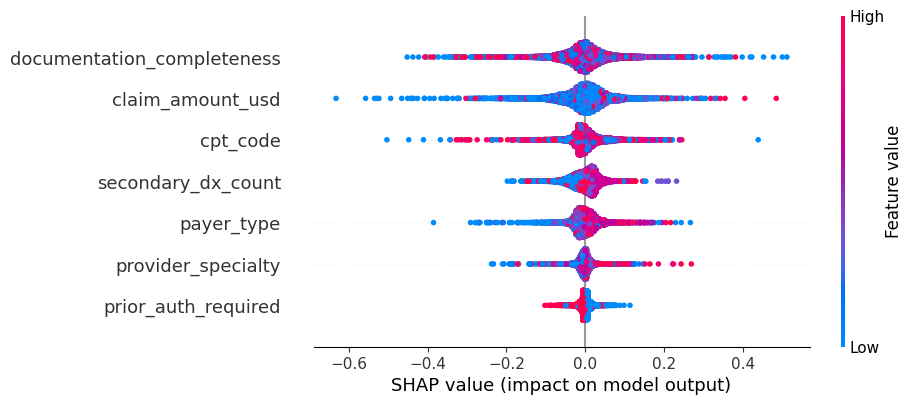

In [6]:
# =============================================================
# SHAP
# =============================================================

import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_val)

shap.plots.beeswarm(shap_values)

<div style="
    background:#2a2a4a;
    padding:20px;
    border-radius:10px;
    color:white;
">
<h2> ROI Simulation</h2>
</div>

In [7]:
# =============================================================
# ROI Calculation
# =============================================================

monthly_claims = 10000
denial_rate = 0.28
avg_claim = 1800

predicted_denials = int(monthly_claims * denial_rate)

recovered = int(predicted_denials * 0.4)

revenue_saved = recovered * avg_claim

print(f"Estimated Monthly Revenue Saved: ${revenue_saved:,}")

Estimated Monthly Revenue Saved: $2,016,000


<div style="
    background:#2a2a4a;
    padding:20px;
    border-radius:10px;
    color:white;
">

<h2> Final Thoughts</h2>

<p>
ML can transform RCM from reactive → proactive.
</p>

<ul>
<li> Predict denials early</li>
<li> Reduce revenue leakage</li>
<li> Improve operational efficiency</li>
</ul>

</div>